In [104]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
style.use('ggplot')

In [105]:
horas = ['9-10', '10-11', '11-12', '12-13', '13-14', '14-15', '15-16', '16-17', '17-18']
lambdas = [50, 55, 45, 35, 20, 35, 40, 60, 10]

df = pd.DataFrame({
    'hora':horas,
    'lambda':lambdas
})
df

,hora,lambda
0,9-10,50
1,10-11,55
2,11-12,45
3,12-13,35
4,13-14,20
5,14-15,35
6,15-16,40
7,16-17,60
8,17-18,10


In [106]:
# Mezcla de operaciones
probs = [0.33, 0.28, 0.25, 0.07, 0.03]
tiempos = [4, 2, 2, 4, 8]

In [107]:
def calcular_mu(probs, tiempos):
    """
    Calcula la tasa de servicio μ (clientes por hora)
    a partir de probabilidades y tiempos promedio (en minutos).
    """
    
    # Probabilidad conocida
    p_conocida = sum(probs)
    
    # Tiempo promedio ponderado conocido
    t_prom_conocido = sum(p * t for p, t in zip(probs, tiempos))
    
    # Probabilidad restante
    p_rest = 1 - p_conocida
    
    # Tiempo promedio del resto (ajuste proporcional)
    t_resto = t_prom_conocido / p_conocida
    
    # Tiempo promedio total
    t_prom_min = t_prom_conocido + p_rest * t_resto
    
    # Convertimos a clientes por hora
    mu = 60 / t_prom_min
    
    return mu


In [108]:

def metricas_mmc(lam, mu, c):

    r = lam / mu
    rho = lam / (c * mu)

    if rho >= 1:
        return None, None, None, None

    suma = sum((r**k)/math.factorial(k) for k in range(c))
    termino_final = (r**c)/(math.factorial(c)*(1-rho))
    P0 = 1/(suma + termino_final)

    Lq = (P0 * (r**c) * rho) / (math.factorial(c) * (1-rho)**2)
    Wq = Lq / lam
    W = Wq + (1/mu)
    L = lam * W

    return Lq, Wq, W, L

In [109]:
# frecuencia de operaciones 9-10
probs09_10 = [0.33, 0.28, 0.25, 0.07, 0.03]
tiempos09_10 = [4, 2, 2, 4, 8]

# frecuencia de operaciones 10-11
probs10_11 = [0.34, 0.29, 0.20, 0.06, 0.02]
tiempos10_11 = [4, 2, 2, 4, 8]

# frecuencia de operaciones 11-12
probs11_12 = [0.20, 0.33, 0.15, 0.17, 0.13]
tiempos11_12 = [4, 2, 2, 4, 8]

# frecuencia de operaciones 12-13
probs12_13 = [0.23, 0.34, 0.22, 0.11, 0.04]
tiempos12_13 = [4, 2, 2, 4, 8]

# frecuencia de operaciones 13-14
probs13_14 = [0.33, 0.18, 0.22, 0.04, 0.13]
tiempos13_14 = [4, 2, 2, 4, 8]

# frecuencia de operaciones 14-15
probs14_15 = [0.13, 0.38, 0.22, 0.02, 0.14]
tiempos14_15 = [4, 2, 2, 4, 8]

# frecuencia de operaciones 15-16
probs15_16 = [0.21, 0.21, 0.33, 0.17, 0.02]
tiempos15_16 = [4, 2, 2, 4, 8]

# frecuencia de operaciones 16-17
probs16_17 = [0.13, 0.18, 0.15, 0.17, 0.23]
tiempos16_17 = [4, 2, 2, 4, 8]

# frecuencia de operaciones 17-18
probs17_18 = [0.23, 0.20, 0.05, 0.01, 0.33]
tiempos17_18 = [4, 2, 2, 4, 8]

tipos = ["Op1", "Op2", "Op3", "Op4", "Op5"]

df_operaciones = pd.DataFrame({
    "Operacion": tipos,
    "Tiempo_min": [4, 2, 2, 4, 8],
    "9-10": probs09_10,
    "10-11": probs10_11,
    "11-12": probs11_12,
    "12-13": probs12_13,
    "13-14": probs13_14,
    "14-15": probs14_15,
    "15-16": probs15_16,
    "16-17": probs16_17,
    "17-18": probs17_18
})

df_operaciones

,Operacion,Tiempo_min,9-10,10-11,11-12,12-13,13-14,14-15,15-16,16-17,17-18
0,Op1,4,0.33,0.34,0.20,0.23,0.33,0.13,0.21,0.13,0.23
1,Op2,2,0.28,0.29,0.33,0.34,0.18,0.38,0.21,0.18,0.20
2,Op3,2,0.25,0.20,0.15,0.22,0.22,0.22,0.33,0.15,0.05
3,Op4,4,0.07,0.06,0.17,0.11,0.04,0.02,0.17,0.17,0.01
4,Op5,8,0.03,0.02,0.13,0.04,0.13,0.14,0.02,0.23,0.33


In [112]:
# df["mu"] = df.apply(lambda row: calcular_mu(probs, tiempos), axis=1)
mu_por_hora = {}


for hora in df_operaciones.columns[2:]:  # saltamos Operacion y Tiempo_min
    probs = df_operaciones[hora]
    mu_por_hora[hora] = calcular_mu(probs, tiempos)

df["mu"] = df["hora"].map(mu_por_hora)

df["s"] = 5

df["rho"] = df["lambda"] / (df["s"] * df["mu"])

c = 5

df[["Lq","Wq","W","L"]] = df.apply(
    lambda row: metricas_mmc(row["lambda"], row["mu"], c),
    axis=1,
    result_type="expand"
)

df

,hora,lambda,mu,s,rho,Lq,Wq,W,L
0,9-10,50,19.862069,5,0.503472,0.135310,0.002706,0.053053,2.652671
1,10-11,55,19.927007,5,0.552015,0.222906,0.004053,0.054236,2.982979
2,11-12,45,16.896552,5,0.532653,0.183449,0.004077,0.063260,2.846715
3,12-13,35,20.142857,5,0.347518,0.018890,0.000540,0.050185,1.756479
4,13-14,20,16.265060,5,0.245926,0.002961,0.000148,0.061630,1.232590
5,14-15,35,18.287671,5,0.382772,0.031526,0.000901,0.055582,1.945384
6,15-16,40,20.434783,5,0.391489,0.035518,0.000888,0.049824,1.992965
7,16-17,60,13.945946,5,0.860465,4.171490,0.069525,0.141230,8.473816
8,17-18,10,12.000000,5,0.166667,0.000349,0.000035,0.083368,0.833683


In [113]:
lam = 60
mu = 13.945946

for c in [5, 6]:
    Lq, Wq, W, L = metricas_mmc(lam, mu, c)
    
    print(f"\nServidores: {c}")
    print(f"ρ = {lam/(c*mu):.3f}")
    print(f"Lq = {Lq:.3f} clientes")
    print(f"Wq = {Wq*60:.2f} minutos")
    print(f"W total = {W*60:.2f} minutos")


Servidores: 5
ρ = 0.860
Lq = 4.171 clientes
Wq = 4.17 minutos
W total = 8.47 minutos

Servidores: 6
ρ = 0.717
Lq = 0.922 clientes
Wq = 0.92 minutos
W total = 5.22 minutos


In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import math

lam = 60
mu = 13.945946

def metricas_mmc(lam, mu, c):
    r = lam / mu
    rho = lam / (c * mu)

    if rho >= 1:
        return None, None, None, None

    suma = sum((r**k)/math.factorial(k) for k in range(c))
    termino_final = (r**c)/(math.factorial(c)*(1-rho))
    P0 = 1/(suma + termino_final)

    Lq = (P0 * (r**c) * rho) / (math.factorial(c) * (1-rho)**2)
    Wq = Lq / lam
    W = Wq + (1/mu)
    L = lam * W

    return Lq, Wq, W, L

resultados = []

for c in range(3, 11):  # probamos de 3 a 10 servidores
    Lq, Wq, W, L = metricas_mmc(lam, mu, c)
    if Wq is not None:
        resultados.append([c, Wq * 60])  # en minutos

df_wq = pd.DataFrame(resultados, columns=["servidores", "Wq_min"])

In [118]:
df_wq

,servidores,Wq_min
0,5,4.171490
1,6,0.922497
2,7,0.290029
3,8,0.097836
4,9,0.032916
5,10,0.010729


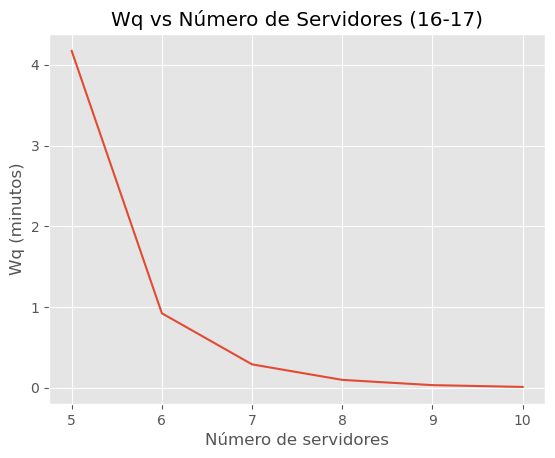

In [117]:
plt.figure()
plt.plot(df_wq["servidores"], df_wq["Wq_min"])
plt.xlabel("Número de servidores")
plt.ylabel("Wq (minutos)")
plt.title("Wq vs Número de Servidores (16-17)")
plt.show()